# Figures for Laurianne's NAMS 2025 presentation

Prepared by: Molly Dougher

Adapted from: Xinhong Liu xliu27@nd.edu

### Import library

In [1]:
from utility import *

future: the set contained only NumericConstant and _PythonCallbackFunctionID,
and provided no meaningful value to clients or walkers.  Users should likely
handle these types in the same manner as immutable Params.  (deprecated in
6.7.2) (called from <frozen importlib._bootstrap>:241)
'_BlockData'.  The class '_BlockData' has been renamed to 'BlockData'.
(deprecated in 6.7.2) (called from /opt/anaconda3/envs/dynamic-
diafiltration/lib/python3.11/site-packages/idaes/core/base/process_base.py:78)
from '_GeneralExpressionData'.  The class '_GeneralExpressionData' has been
renamed to 'ExpressionData'.  (deprecated in 6.7.2) (called from
/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-
packages/idaes/core/base/var_like_expression.py:31)


# NF90 (DATA1)
## Concentrations: Figure 2C-D

In [2]:
from DATA1_matlab.diafiltration_plots import plot_sim_comparison as plot_sim_comparisonDATA1


Loading data file = DATA1_matlab/data/data_stru-dataset511.12.mat 


Loading data file = DATA1_matlab/data/511.12 concpolar/fit_stru.mat 



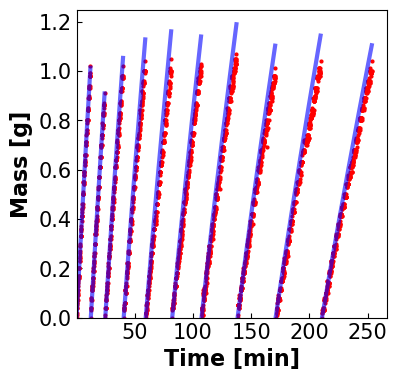

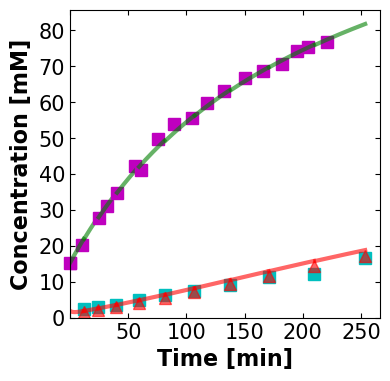

In [3]:
# pull the data from DATA1_matlab/DiafiltrationPaperPlots.ipynb
### Diafiltration
#### M1(conctration polarization, continuous retentate)
# Figure 2, 5, 6, S3, S4
data_stru90 = loadmat('DATA1_matlab/data/data_stru-dataset511.12.mat')['data_stru']
fit_stru90 = loadmat('DATA1_matlab/data/511.12 concpolar/fit_stru.mat')['fit_stru']
plot_sim_comparisonDATA1(data_stru90,fit_stru90,plot_pred=True,cond=True,lg=False)

## Interfacial concentrations

In [4]:
sim_stru90 = fit_stru90["sim_stru"]
        

In [5]:
cF_exp_90 = {}
cF_exp_index_90 = {}

for vial in range(data_stru90['data_config']['n']):
        cF_exp_90[vial] = [x for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x)!='nan']
        cF_exp_index_90[vial] = [data_stru90["data_raw"][vial]['cF_exp'].index(x) for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x)!='nan']

print(cF_exp_90)
print(len(cF_exp_90))
print(cF_exp_index_90)
print(len(cF_exp_index_90))

cF_avg = []
for vial, conc in cF_exp_90.items():
        cF_avg.append(np.average(conc))

print(cF_avg)

{0: [15.20517956, 20.17925714], 1: [], 2: [27.74228235, 31.0364], 3: [34.73451321, 42.10616744], 4: [41.21821818, 49.70306667], 5: [53.94549091, 55.5364], 6: [59.79315676, 63.0364], 7: [66.67276364, 68.6614], 8: [70.77833548, 74.22284068, 75.4501931], 9: [76.72061053]}
10
{0: [2, 126], 1: [], 2: [0, 90], 3: [0, 180], 4: [20, 193], 5: [86, 270], 6: [129, 300], 7: [146, 326], 8: [134, 284, 404], 9: [116]}
10
[17.69221835, nan, 29.389341175, 38.420340325, 45.460642425, 54.740945455, 61.41477838, 67.66708181999999, 73.48378975333334, 76.72061053]


/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


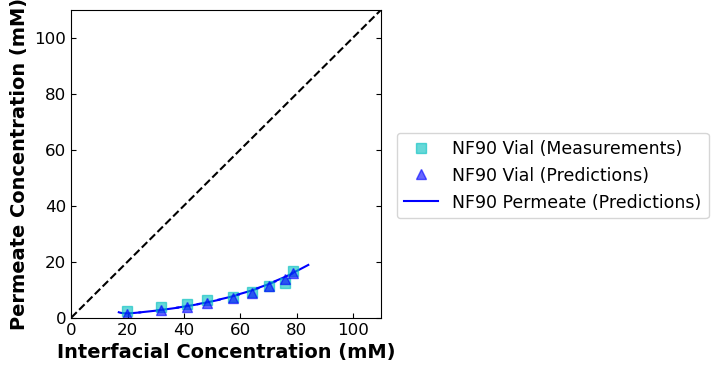

In [6]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
cIn_sim = []
fig = plt.figure(figsize=(4,4))

for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'b-',linewidth=1.5)

    # vial measurements, plot at the bulk cIn,exp
    plt.plot(cIn_exp,data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)

    # vial predictions, plot the bulk predicted cV and the same cIn as exp
    f = interpolate.interp1d(cIn_sim, sim_stru90[vial]['cV'])
    plt.plot(cIn_exp,f(cIn_exp),'b^',markersize=7, alpha=0.6)
    
    cIn_sim = []


plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,label='NF90 Vial (Measurements)', alpha=0.6)
plt.plot([],[],'b^',markersize=7,label='NF90 Vial (Predictions)', alpha=0.6)        
plt.plot([],[],'b-',linewidth=1.5,label='NF90 Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

plt.show()

## Solute permeability

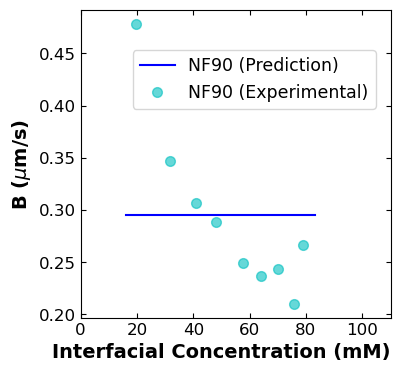

In [7]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s
cIn = []

fig = plt.figure(figsize=(4,4))

# simulated
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'b-',linewidth=1.5)

# experimental
for vial in range(data_stru90['data_config']['n']):
    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    # calculate exp R = 1-(cp/cin) per vial
    vial_R_exp = 1 - (data_stru90["data_raw"][vial]['cV_avg'] / cIn_exp)
    # calculate exp B = Jw((1-R)/R) per vial
    vial_B90_exp = vial_water_flux_exp * ((1-vial_R_exp)/vial_R_exp) *10000 #um/s

    plt.plot(cIn_exp,vial_B90_exp,'co',markersize=7, alpha=0.6)

    cIn = []

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'b-',linewidth=1.5,label='NF90 (Prediction)')
plt.plot([],[],'co',markersize=7, alpha=0.6,label='NF90 (Experimental)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.98, 0.65))
plt.xlim(left=0,right=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

# NF270 (DATA2)
## Concentrations-Lag: Figure 6A-C

### Parameter estimation with a linear B

In [8]:
data_stru270 = loadmat('data_library/data_stru-dataset270511.123.mat')['data_stru']
sim_stru270=[]


Loading data file = data_library/data_stru-dataset270511.123.mat 



###################################################################
Creating and solving the Pyomo model with the following settings: 
mode = Lag
theta = {'Lp': 11, 'beta_c': 15, 'beta_0': 1, 'beta_1': 0.01, 'sigma': 1.0, 'S0': 0}
sim_opt = False
B_form = 1
 


CasADi - 2025-05-08 16:17:04 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated. Set the time grid by proving additional argument to the 'integrator' call instead.") [.../casadi/core/integrator.cpp:496]


Ipopt 3.13.2: linear_solver=ma97
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

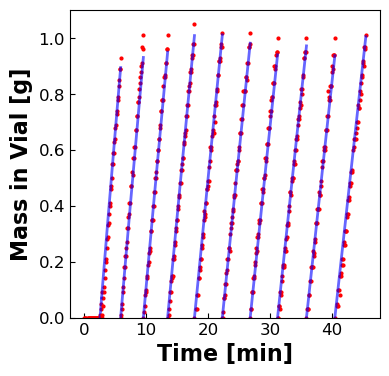

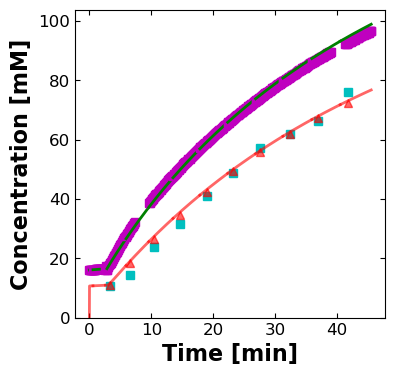

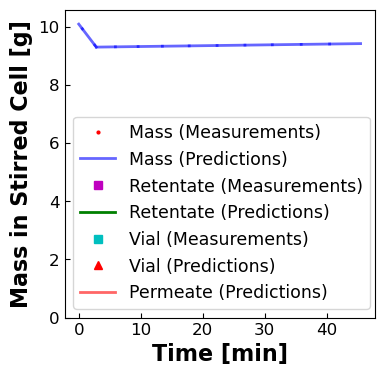

In [9]:
mode = 'Lag'
theta = {'Lp': 11,
  'beta_c': 15,
  'beta_0': 1,
  'beta_1': 0.01,
  'sigma': 1.0,
  'S0': 0}
fit_stru270, sim_stru270, sim_inter270 = solve_model(data_stru270, mode, theta, sim_opt=False, B_form=1,LOUD=True)
plot_sim_comparison(data_stru270,sim_stru270,stirc_mass=True,plot_pred=True,lg=True,LOUD=True)

In [10]:
# for i in range(data_stru270['data_config']['n']):
print(data_stru270['data_config'])

{'M_F0': 10.09, 'C_F0': 16.24262844, 'M_O': -0.67, 'C_D': 128.5309872, 'nc': 1, 'namec': 'KCl', 'ni': 2, 'delP': 4.071640142, 'Temp': 298, 'Am': 4.1, 'rho': 1, 'Lp0': 11.84370879, 'B0': 16.85468687, 'sigma0': 0.380724777, 'theta0': [11.84370879, 16.85468687, 0.380724777], 'n': 13, 'n_extra': 3, 'n_v0': 3, 'n_h': 1, 'n_A': 3, 'nr': 0}


100


(-0.12916666666666668, 2.8)

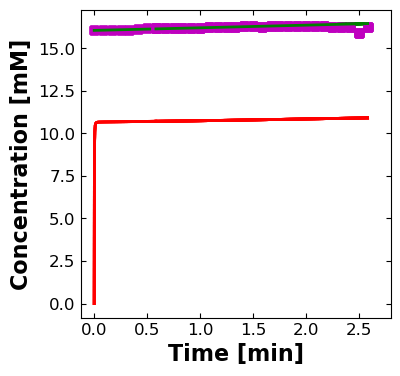

In [11]:
# plot concentration data/prediction comparison
fig,ax = plt.subplots(figsize=(4,4))

t_delay = data_stru270['data_raw'][0]['time'][0]
print(t_delay)
t_start = 0

for i in range(data_stru270['data_config']['n']):
    for pt in range(len((data_stru270['data_raw'][i]['time']))):
        if (data_stru270['data_raw'][i]['time'][pt] <= 200):
            # if type(data_stru270['data_raw'][i]['cV_avg']) != list:
                # plt.plot((float(data_stru270['data_raw'][i]['time'][-1])-t_delay-t_start)/60,
                #             data_stru270['data_raw'][i]['cV_avg'],
                #             'cs',markersize=6)
            # else:
            #     plt.plot([(float(t)-t_delay-t_start)/60 for t in data_stru270['data_raw'][i]['time']],
            #                 data_stru270['data_raw'][i]['cV_avg'],'cs',markersize=6,clip_on=False)
            plt.plot([(float(t)-t_delay-t_start)/60 for t in data_stru270['data_raw'][i]['time']],
                        data_stru270['data_raw'][i]['cF_exp'],'ms',markersize=6,clip_on=False)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cF'],
                        'g',linewidth=2)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cH'],
                        'r-',linewidth=2,alpha=.6)
            if type(data_stru270['data_raw'][i]['cV_avg']) != list:
                plt.plot((sim_stru270[i]['time'][-1]-t_start)/60,
                            sim_stru270[i]['cV'][-1],
                            'r^',linewidth=2,alpha=.6)
            else:
                time = data_stru270['data_raw'][i]['time']-t_delay
                index = ~np.isnan(data_stru270['data_raw'][i]['cV_avg'])
                t = [time[i] for i, val in enumerate(index) if val]
                f = interpolate.interp1d(sim_stru270[i]['time'],sim_stru270[i]['cV'], fill_value='extrapolate')  
                plt.plot([(ti-t_start)/60 for ti in t],
                            f(t),
                            'r^',linewidth=2,alpha=.6)
            
plt.xlabel('Time [min]',fontsize=16,fontweight='bold')
plt.ylabel('Concentration [mM]',fontsize=16,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.xlim(right=2.8)

In [12]:
cV_exp_values = [0,0,0]
for vial_dict in data_stru270["data_raw"]:
    for variable, values in vial_dict.items():
        if variable == 'cV_avg':
            for x in values:
                if str(x) != 'nan':
                    cV_exp_values.append(x)
print(cV_exp_values)
print(len(cV_exp_values))

[0, 0, 0, 10.63030414, 14.22108286, 23.72155353, 31.57139223, 40.92372016, 48.77230198, 57.01986578, 61.91865276, 66.15705841, 75.88025664]
13


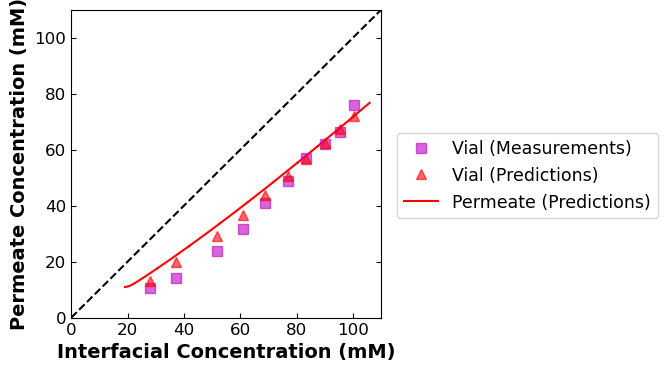

In [13]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)

fig = plt.figure(figsize=(4,4))

for vial in range(data_stru270['data_config']['n']):
    # skip the first three entries
    if vial >= 3:
        # plot permeate predictions
        plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["cH"],'r-',linewidth=1.5)

        # calculate exp water flux per vial
        vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
        vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
        # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
        # remove nan from cF_exp
        cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
        cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
        cF_vals = []

        # vial measurements, plot at the bulk cIn,exp
        plt.plot(cIn_exp270, cV_exp_values[vial], 'ms', markersize=7, alpha=0.6)

        # vial predictions, plot the bulk predicted cV and the same cIn as exp
        f = interpolate.interp1d(sim_stru270[vial]["cIn"], sim_stru270[vial]['cV'])
        plt.plot(cIn_exp270,f(cIn_exp270),'r^',markersize=7, alpha=0.6)

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'ms',markersize=7,label='Vial (Measurements)',alpha=0.6)
plt.plot([],[],'r^',markersize=7,label='Vial (Predictions)',alpha=0.6)        
plt.plot([],[],'r-',linewidth=1.5,label='Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

## Solute Permeability

In [14]:
for vial, info in sim_stru270.items():
    for var, vals in info.items():
        print(var)
        print(vals)

time
[0, 0.116655, 0.233345, 0.35000000000000003, 0.466655, 0.583345, 0.7000000000000001, 0.816655, 0.933345, 1.05, 1.166655, 1.283345, 1.4000000000000001, 1.516655, 1.633345, 1.75, 1.866655, 1.9833450000000001, 2.1, 2.216655, 2.333345, 2.45, 2.566655, 2.683345, 2.8000000000000003, 2.916655, 3.0333449999999997, 3.15, 3.266655, 3.3833450000000003, 3.5, 3.6166549999999997, 3.733345, 3.85, 3.9666550000000003, 4.0833450000000004, 4.2, 4.316655, 4.433345, 4.55, 4.666655, 4.783345000000001, 4.9, 5.016654999999999, 5.133344999999999, 5.25, 5.366655, 5.483345, 5.6000000000000005, 5.716655, 5.8333450000000004, 5.95, 6.066655, 6.183345, 6.3, 6.4166549999999996, 6.533345, 6.65, 6.766655, 6.883345, 7.0, 7.116655000000001, 7.233345, 7.35, 7.466654999999999, 7.583345, 7.7, 7.816655, 7.933345, 8.05, 8.166655, 8.283344999999999, 8.4, 8.516655, 8.633345, 8.75, 8.866655, 8.983345, 9.1, 9.216655, 9.333345, 9.450000000000001, 9.566654999999999, 9.683345, 9.8, 9.916655, 10.033345, 10.149999999999999, 10.26

In [15]:
data_stru270['data_config']['C_F0']

16.24262844

In [16]:
print(sim_stru270[vial]["time"])
print(sim_stru270[vial]["mV"])

[2430, 2430.9999, 2432.0001, 2433.0, 2433.9999, 2435.0001, 2436.0, 2436.9999, 2438.0001, 2439.0, 2439.9999, 2441.0001, 2442.0, 2442.9999, 2444.0001, 2445.0, 2445.9999, 2447.0001, 2448.0, 2448.9999, 2450.0001, 2451.0, 2451.9999, 2453.0001, 2454.0, 2454.9999, 2456.0001, 2457.0, 2457.9999, 2459.0001, 2460.0, 2460.9999, 2462.0001, 2463.0, 2463.9999, 2465.0001, 2466.0, 2466.9999, 2468.0001, 2469.0, 2469.9999, 2471.0001, 2472.0, 2472.9999, 2474.0001, 2475.0, 2475.9999, 2477.0001, 2478.0, 2478.9999, 2480.0001, 2481.0, 2481.9999, 2483.0001, 2484.0, 2484.9999, 2486.0001, 2487.0, 2487.9999, 2489.0001, 2490.0, 2490.9999, 2492.0001, 2493.0, 2493.9999, 2495.0001, 2496.0, 2496.9999, 2498.0001, 2499.0, 2499.9999, 2501.0001, 2502.0, 2502.9999, 2504.0001, 2505.0, 2505.9999, 2507.0001, 2508.0, 2508.9999, 2510.0001, 2511.0, 2511.9999, 2513.0001, 2514.0, 2514.9999, 2516.0001, 2517.0, 2517.9999, 2519.0001, 2520.0, 2520.9999, 2522.0001, 2523.0, 2523.9999, 2525.0001, 2526.0, 2526.9999, 2528.0001, 2529.0, 252

In [17]:
# determine the units of the reported B values
Jw_calc = []
Jw_reported_avg = []
for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                B_sim_reported = [x for x in sim_stru270[vial]["B"]]# um/s
                Jw_reported = [x for x in sim_stru270[vial]["Jw"]]# cm3/cm2/s

                # calculate simulated water flux
                vial_dmdt_sim270 = (sim_stru270[vial]["mV"][-1] - sim_stru270[vial]["mV"][0]) / (sim_stru270[vial]["time"][-1] - sim_stru270[vial]["time"][0]) # g/s
                vial_water_flux_sim270 = (1/4.1)*vial_dmdt_sim270 # cm3/cm2/s
                Jw_calc.append(vial_water_flux_sim270)
                B_sim_calc = [(vial_water_flux_sim270*10000*(1.064929254383047+0.015171422560448225*cint)) for cint in sim_stru270[vial]["cIn"]]
                Jw_reported_avg.append(np.average(Jw_reported))

print(B_sim_reported)# um/s
# print(Jw_reported)# cm3/cm2/s
# print(Jw_reported_avg)# cm3/cm2/s
print(B_sim_calc)
# print(Jw_calc)# cm3/cm2/s

[2.582592727496947, 2.5829041660684315, 2.583215579800412, 2.5835267819765573, 2.5838378660620203, 2.5841489253802243, 2.5844597734272803, 2.584770503561925, 2.585081209001378, 2.5853917034538707, 2.58570208017188, 2.586012432266583, 2.5863225736580047, 2.586632597492524, 2.5869425967754296, 2.587252385638222, 2.5875620571213394, 2.58787170412434, 2.5881811409898794, 2.5884904606526127, 2.5887997559065266, 2.5891088413051118, 2.5894178096773977, 2.589726753711958, 2.5900354881728003, 2.590344105783486, 2.5906526991273333, 2.590961083178549, 2.591269350555385, 2.5915775937360612, 2.591885627904666, 2.5921935455743004, 2.5925014391182426, 2.592809123930147, 2.5931166924181204, 2.5934242368506584, 2.5937315728306642, 2.59403879266141, 2.594345988506762, 2.594652976178561, 2.5949598478753995, 2.595266695656673, 2.5955733355428445, 2.595879859627983, 2.5961863598671715, 2.596492652489182, 2.596798829483717, 2.597104982701701, 2.597410928579904, 2.597716759003818, 2.598022565720366, 2.598328

### Experimental B=Jw((1-R)/R) -- Convection only

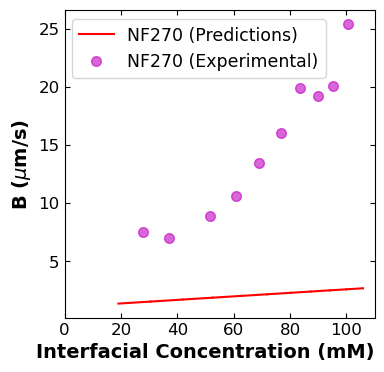

In [18]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s

fig = plt.figure(figsize=(4,4))

for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                # simulated
                plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["B"],'r-',linewidth=1.5)

                # experiental 
                # calculate exp water flux per vial
                vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
                vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
                # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
                # remove nan from cF_exp
                cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
                cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
                cF_vals = []

                # calculate exp R = 1-(cp/cin) per vial
                vial_R_exp270 = 1 - (cV_exp_values[vial] / cIn_exp270)
                # calculate exp B = Jw((1-R)/R) per vial
                vial_B_exp270 = vial_water_flux_exp270 * ((1-vial_R_exp270)/vial_R_exp270) *10000 #um/s

                plt.plot(cIn_exp270,vial_B_exp270,'mo',markersize=7, alpha=0.6)

                

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')
plt.xlim(left=0,right=110)

# ghost point for legend    
plt.plot([],[],'r-',linewidth=1.5,label='NF270 (Predictions)')
plt.plot([],[],'mo',markersize=7,alpha=0.6,label='NF270 (Experimental)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.87, 0.75))
plt.xlim(left=0,right=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

### Experimental B = Jw/Pe * (1-exp(Pe)-R+Rexp(Pe))/(1-R-exp(Pe))

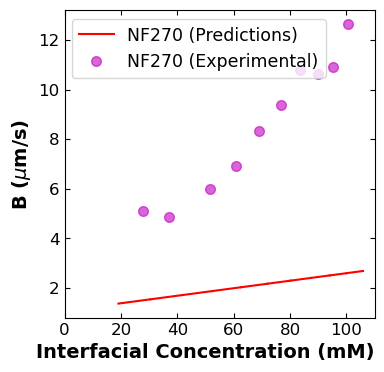

In [19]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s

fig = plt.figure(figsize=(4,4))

for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                # simulated
                B_sim = [x for x in sim_stru270[vial]["B"]]
                plt.plot(sim_stru270[vial]["cIn"],B_sim,'r-',linewidth=1.5)

                # experiental 
                # calculate exp water flux per vial
                vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
                vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
                # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
                # remove nan from cF_exp
                cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
                cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
                cF_vals = []

                # calculate exp R = 1-(cp/cin) per vial
                vial_R_exp270 = 1 - (cV_exp_values[vial] / cIn_exp270)
                # calculate exp Pe = Jw/k
                vial_Pe_exp_270 = vial_water_flux_exp270 / k
                # calculate exp B = Jw/Pe * (1-exp(Pe)-R+Rexp(Pe))/(1-R-exp(Pe))
                vial_B_exp270 = (
                        vial_water_flux_exp270*(
                                1-np.exp(vial_Pe_exp_270)-vial_R_exp270+vial_R_exp270*np.exp(vial_Pe_exp_270)
                        )
                ) / (
                        vial_Pe_exp_270*(1-vial_R_exp270-np.exp(vial_Pe_exp_270))
                ) * 10000 #um/s

                plt.plot(cIn_exp270,vial_B_exp270,'mo',markersize=7, alpha=0.6)

                

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')
plt.xlim(left=0,right=110)

# ghost point for legend    
plt.plot([],[],'r-',linewidth=1.5,label='NF270 (Predictions)')
plt.plot([],[],'mo',markersize=7,alpha=0.6,label='NF270 (Experimental)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.87, 0.75))
plt.xlim(left=0,right=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

# Combined plots for NF90/NF270
## Concentrations

<Figure size 400x400 with 0 Axes>

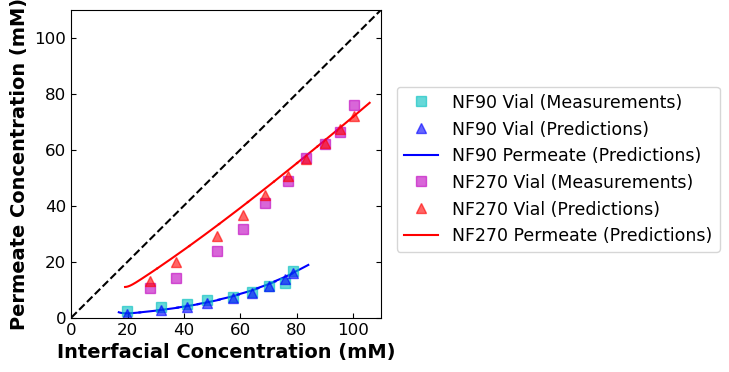

In [20]:
fig = plt.figure(figsize=(4,4))
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
#-------------------------------------------------------------------------------------------------------------------------------
# NF 90
cIn_sim = []
fig = plt.figure(figsize=(4,4))

for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'b-',linewidth=1.5)

    # vial measurements, plot at the bulk cIn,exp
    plt.plot(cIn_exp,data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)

    # vial predictions, plot the bulk predicted cV and the same cIn as exp
    f = interpolate.interp1d(cIn_sim, sim_stru90[vial]['cV'])
    plt.plot(cIn_exp,f(cIn_exp),'b^',markersize=7, alpha=0.6)
    
    cIn_sim = []
#-------------------------------------------------------------------------------------------------------------------------------
# NF 270
for vial in range(data_stru270['data_config']['n']):
    # skip the first three entries
    if vial >= 3:
        # plot permeate predictions
        plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["cH"],'r-',linewidth=1.5)

        # calculate exp water flux per vial
        vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
        vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
        # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
        # remove nan from cF_exp
        cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
        cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
        cF_vals = []

        # vial measurements, plot at the bulk cIn,exp
        plt.plot(cIn_exp270, cV_exp_values[vial], 'ms', markersize=7, alpha=0.6)

        # vial predictions, plot the bulk predicted cV and the same cIn as exp
        f = interpolate.interp1d(sim_stru270[vial]["cIn"], sim_stru270[vial]['cV'])
        plt.plot(cIn_exp270,f(cIn_exp270),'r^',markersize=7, alpha=0.6)
#-------------------------------------------------------------------------------------------------------------------------------

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,alpha=0.6,label='NF90 Vial (Measurements)')
plt.plot([],[],'b^',markersize=7,alpha=0.6,label='NF90 Vial (Predictions)')        
plt.plot([],[],'b-',linewidth=1.5,label='NF90 Permeate (Predictions)')
plt.plot([],[],'ms',markersize=7,alpha=0.6,label='NF270 Vial (Measurements)')
plt.plot([],[],'r^',markersize=7,alpha=0.6,label='NF270 Vial (Predictions)')        
plt.plot([],[],'r-',linewidth=1.5,label='NF270 Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.75),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in", right=True)

## Solute Permeability

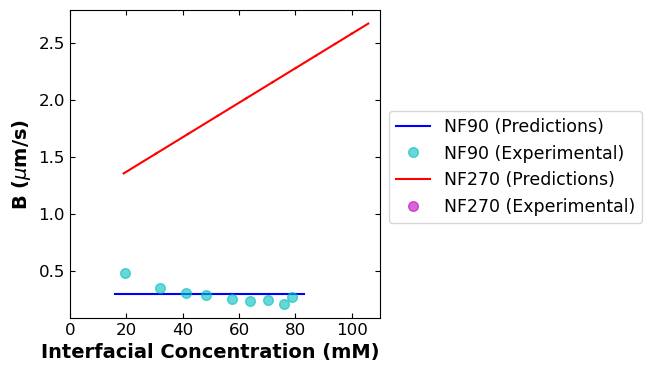

In [21]:
fig = plt.figure(figsize=(4,4))
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s
#-------------------------------------------------------------------------------------------------------------------------------
# NF 90

cIn = []

# simulated
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'b-',linewidth=1.5)

# experimental
for vial in range(data_stru90['data_config']['n']):
    ## calculate exp water flux per vial
    vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # calculate exp cIn per vial
    cIn_exp = (cF_avg[vial]-data_stru90["data_raw"][vial]['cV_avg'])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg']
    # calculate exp R = 1-(cp/cin) per vial
    vial_R_exp = 1 - (data_stru90["data_raw"][vial]['cV_avg'] / cIn_exp)
    # calculate exp B = Jw((1-R)/R) per vial
    vial_B90_exp = vial_water_flux_exp * ((1-vial_R_exp)/vial_R_exp) *10000 #um/s

    plt.plot(cIn_exp,vial_B90_exp,'co',markersize=7, alpha=0.6)

    cIn = []
#-------------------------------------------------------------------------------------------------------------------------------
# NF 270
for vial in range(data_stru270['data_config']['n']):
        # skip the first three entries
        if vial >= 3:
                # simulated
                plt.plot(sim_stru270[vial]["cIn"],sim_stru270[vial]["B"],'r-',linewidth=1.5)

                # experiental 
                # calculate exp water flux per vial
                vial_dmdt_exp270 = (data_stru270["data_raw"][vial]["mass"][-1] - data_stru270["data_raw"][vial]["mass"][0]) / (data_stru270["data_raw"][vial]["time"][-1] - data_stru270["data_raw"][vial]["time"][0])
                vial_water_flux_exp270 = (1/4.1)*vial_dmdt_exp270 # cm3/cm2/s
                # print(vial_water_flux_exp270)
                # calculate exp cIn per vial uses bulk (average) measurements for retentate and vial
                # remove nan from cF_exp
                cF_vals = [x for x in data_stru270["data_raw"][vial]["cF_exp"] if str(x) != 'nan']
                cIn_exp270 = (np.average(cF_vals)-cV_exp_values[vial])*np.exp(vial_water_flux_exp270/k)+cV_exp_values[vial]
                cF_vals = []

                # TODO: calculate exp. B after LE sends notes
                # # calculate exp R = 1-(cp/cin) per vial
                # vial_R_exp270 = 1 - (cV_exp_values[vial] / cIn_exp270)
                # # calculate exp B = Jw((1-R)/R) per vial
                # vial_B270_exp = vial_water_flux_exp270 * ((1-vial_R_exp270)/vial_R_exp270) *10000 #um/s

                # plt.plot(cIn_exp270,vial_B270_exp,'mo',markersize=7, alpha=0.6)
#-------------------------------------------------------------------------------------------------------------------------------

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'b-',linewidth=1.5,label='NF90 (Predictions)')
plt.plot([],[],'co',markersize=7, alpha=0.6,label='NF90 (Experimental)')
plt.plot([],[],'r-',linewidth=1.5,label='NF270 (Predictions)')
plt.plot([],[],'mo',markersize=7, alpha=0.6,label='NF270 (Experimental)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1, 0.7))
plt.xlim(left=0,right=110)
# plt.ylim(bottom=0,top=110)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)

plt.show()